First 5 rows:
    Patient_ID  Age  Gender  Blood_Pressure  Sugar_Level  Cholesterol  \
0           1   57    Male             114           74          217   
1           2   63  Female             109          123          225   
2           3   32    Male             136           77          278   
3           4   28    Male             131          106          234   
4           5   29    Male             103           75          261   

   Heart_Rate  
0          67  
1         105  
2         108  
3         117  
4          66  

Average Values:
 Patient_ID        5000.5000
Age                 49.8992
Blood_Pressure     130.3050
Sugar_Level        134.7937
Cholesterol        225.3627
Heart_Rate          90.0828
dtype: float64

Gender Count:
 Gender
Male      5066
Female    4934
Name: count, dtype: int64

Risk Count:
 Risk_Level
High    8292
Low     1708
Name: count, dtype: int64


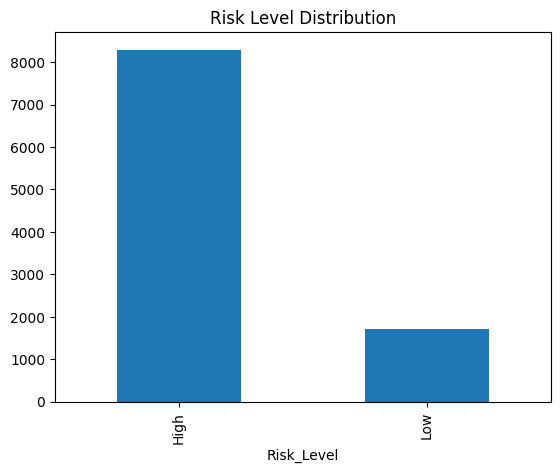

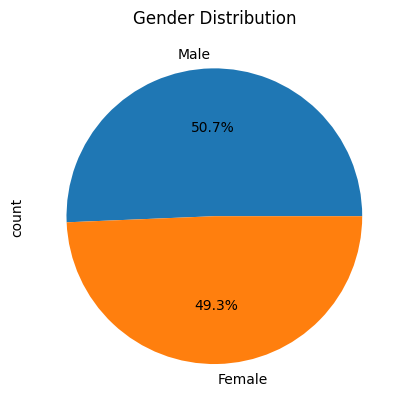

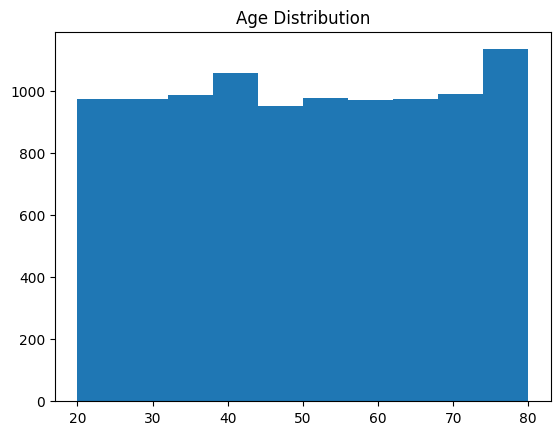

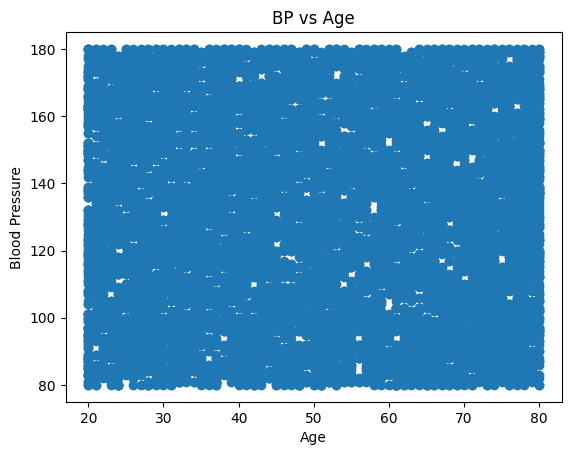

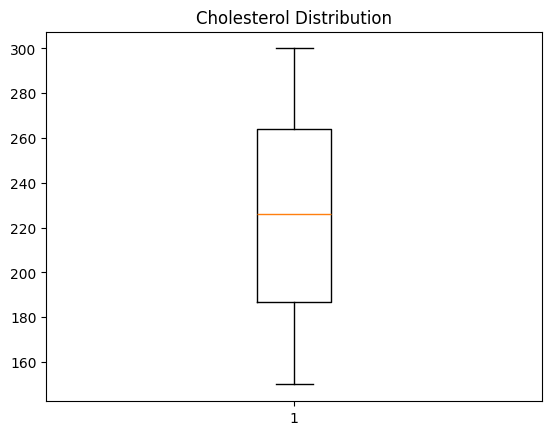

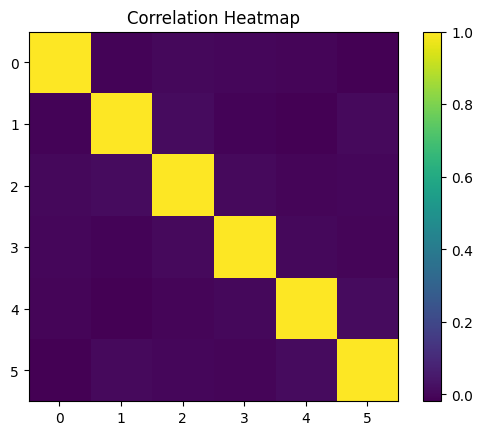

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)

n = 10000

data = pd.DataFrame({
    "Patient_ID": range(1, n+1),
    "Age": np.random.randint(20, 81, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "Blood_Pressure": np.random.randint(80, 181, n),
    "Sugar_Level": np.random.randint(70, 201, n),
    "Cholesterol": np.random.randint(150, 301, n),
    "Heart_Rate": np.random.randint(60, 121, n)
})

print("First 5 rows:\n", data.head())

def heart_rate_status(hr):
    if hr <= 100:
        return "Normal"
    else:
        return "High"

data["HR_Status"] = data["Heart_Rate"].apply(heart_rate_status)

def risk_level(row):
    if (row["Blood_Pressure"] > 140 or
        row["Sugar_Level"] > 160 or
        row["Cholesterol"] > 240 or
        row["Heart_Rate"] > 100):
        return "High"
    else:
        return "Low"

data["Risk_Level"] = data.apply(risk_level, axis=1)

data["Age_Group"] = pd.cut(data["Age"],
                          bins=[20,40,60,80],
                          labels=["Young","Middle","Senior"])

print("\nAverage Values:\n", data.mean(numeric_only=True))

print("\nGender Count:\n", data["Gender"].value_counts())

print("\nRisk Count:\n", data["Risk_Level"].value_counts())

data["Risk_Level"].value_counts().plot(kind="bar")
plt.title("Risk Level Distribution")
plt.show()

data["Gender"].value_counts().plot(kind="pie", autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

plt.hist(data["Age"])
plt.title("Age Distribution")
plt.show()

plt.scatter(data["Age"], data["Blood_Pressure"])
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("BP vs Age")
plt.show()

plt.boxplot(data["Cholesterol"])
plt.title("Cholesterol Distribution")
plt.show()

corr = data.corr(numeric_only=True)
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Heatmap")
plt.show()